## 🔍 1. Configuração do Ambiente e Bibliotecas

Importação de pacotes necessários para manipulação algébrica (`numpy`, `pandas`), visualização (`matplotlib`, `seaborn`) e ferramentas do `scikit-learn` para escalonamento e codificação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

## 🔍 2. Carregamento e Inspeção Inicial das Bases

Nesta etapa fundamental, importamos os dados crus de telemetria (ex: mês de Janeiro) e carregamos as regras de negócio associadas aos alarmes. É o nosso primeiro contato com a informação bruta.

> ⚠️ **Atenção (Alerta de Tipo):** Ao carregar colunas complexas como `Valor` e `Classe`, é possível que o Pandas lance um `DtypeWarning`. Isso ocorre porque há tipos mistos ou caracteres regionais (como vírgulas ao invés de pontos). Resolveremos essa sujeira nos próximos passos!

In [26]:
seed = 42
path = "../data/telemetry/processed"
january = "../data/telemetry/processed/jan.csv"
march =  "../data/telemetry/processed/marco.csv"
#jan = pd.read_csv(january)
jan = pd.read_csv(january, dtype={"Valor": str, "Classe": str})
mar = pd.read_csv(march, dtype={"Valor": str, "Classe": str})


path_alarmes = "../Material/"
alarmes = os.path.join(path_alarmes, "Alarmes - Regra de Negocio.csv")
alar = pd.read_csv(alarmes)

print(f"Esse é o head de março: \n\n {mar.head()}")

Esse é o head de março: 

    Id_Eventos_Telemetria                 Data_Evento             Inicio_Turno  \
0               33767460  2025-03-01 00:08:09.637000  2025-02-28 18:00:00.000   
1               33767461  2025-03-01 00:08:09.637000  2025-02-28 18:00:00.000   
2               33767723  2025-03-01 00:18:13.533000  2025-02-28 18:00:00.000   
3               33767722  2025-03-01 00:18:13.533000  2025-02-28 18:00:00.000   
4               33767836  2025-03-01 00:26:38.687000  2025-02-28 18:00:00.000   

                 Fim_Turno  Dia Localidade     TAG Tag_Frota      Tipo  \
0  2025-03-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
1  2025-03-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
2  2025-03-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
3  2025-03-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
4  2025-03-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   

  Nome_Operador_Anon Matricula_Operador_H

## 🔍 3. Inspeção Estrutural das Amostras

Para entender os dados, olhamos as primeiras linhas (`.head()`). Isso nos dá uma visão clara da disposição das colunas, da nomenclatura dos atributos e do formato que os dados estão assumindo no momento.

In [3]:
head_jan = jan.head()
head_mar = mar.head()
print(f"Head de janeiro \n{head_jan}\n")
print(f"Head de marco \n{head_mar}")

Head de janeiro 
   Id_Eventos_Telemetria                 Data_Evento             Inicio_Turno  \
0                9372078  2025-01-01 00:00:14.553000  2024-12-31 18:00:00.000   
1                9372079  2025-01-01 00:00:14.553000  2024-12-31 18:00:00.000   
2                9372097  2025-01-01 00:02:20.280000  2024-12-31 18:00:00.000   
3                9372111  2025-01-01 00:02:59.077000  2024-12-31 18:00:00.000   
4                9372120  2025-01-01 00:03:37.963000  2024-12-31 18:00:00.000   

                 Fim_Turno  Dia Localidade     TAG Tag_Frota      Tipo  \
0  2025-01-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
1  2025-01-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
2  2025-01-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
3  2025-01-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   
4  2025-01-01 06:00:00.000    1    Itabira  CA5926  793-D 5S  Caminhao   

  Nome_Operador_Anon Matricula_Operador_Hash  Id_Al

## 🔍 4. Exploração Visual por Transposição de Dados

Como nossa base possui **muitas colunas** (tabelas muito largas), visualizar as linhas convencionalmente pode ser difícil. A transposição (`.T`) vira as linhas e colunas de lado, facilitando a auditoria visual detalhada de alguns registros e a verificação do preenchimento.

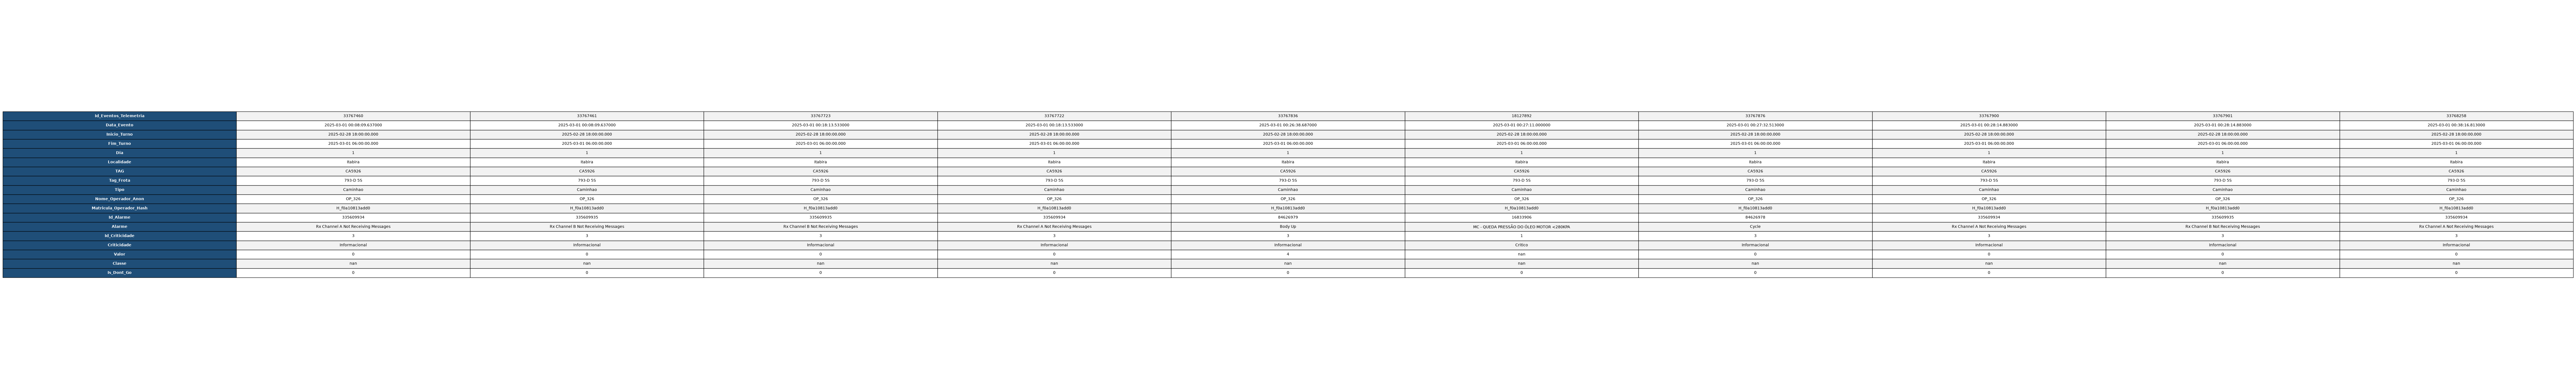

In [4]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 1. Lendo os dados
#df = jan
df = mar
# Pegando as primeiras linhas
df_to_plot = df.head(10)

# --- TRANSPOSIÇÃO DOS DADOS ---
# Transpõe o DataFrame (.T) e transforma o índice (nomes das colunas originais) em uma coluna real
df_transposto = df_to_plot.T.reset_index()

# Configuração do tamanho da figura (ajustado para o formato vertical da transposição)
fig, ax = plt.subplots(figsize=(120, 18))
ax.axis("tight")
ax.axis("off")

# 2. Criar a tabela centralizada
# Como transcrevemos tudo para o corpo da tabela, não passamos 'colLabels' para não duplicar o cabeçalho no topo
the_table = ax.table(
    cellText=df_transposto.values,
    loc="center",
    cellLoc="center",
)

# 3. Travar o tamanho da fonte e dar espaçamento vertical (scale)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.0, 2.0)  # Ajustado para 2.0 para manter um bom respiro vertical

# 4. Estilização Transposta (Coluna da esquerda escura, linhas alternadas no resto)
for (row, col), cell in the_table.get_celld().items():
    if col == 0:
        # Primeira coluna (antigo cabeçalho) fica em Azul Escuro
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#1F4E78")
    else:
        # Linhas alternadas em cinza claro para o restante dos dados
        if row % 2 == 0:
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

# 5. Salva no PDF primeiro
with PdfPages("alarmes_transposto.pdf") as pp:
    pp.savefig(fig, bbox_inches="tight", dpi=200)

# 6. MANDA PLOTAR NA TELA SUCESSO!
plt.show()

## 🔍 5. Diagnóstico de Valores Ausentes (Missing Values)

Um dos passos mais importantes em Data Science é saber o que **está faltando**. Aqui criamos um mapeamento volumétrico e percentual de valores nulos por coluna. Atributos com alta taxa de dados faltantes correm o risco de enviesar ou comprometer o modelo e podem ser candidatos à remoção.

Número de valores faltando.
Id_Eventos_Telemetria: 0 -> 0.00%
Data_Evento: 0 -> 0.00%
Inicio_Turno: 0 -> 0.00%
Fim_Turno: 0 -> 0.00%
Dia: 0 -> 0.00%
Localidade: 0 -> 0.00%
TAG: 0 -> 0.00%
Tag_Frota: 0 -> 0.00%
Tipo: 0 -> 0.00%
Nome_Operador_Anon: 0 -> 0.00%
Matricula_Operador_Hash: 0 -> 0.00%
Id_Alarme: 0 -> 0.00%
Alarme: 0 -> 0.00%
Id_Criticidade: 0 -> 0.00%
Criticidade: 0 -> 0.00%
Valor: 33666 -> 0.62%
Classe: 5290675 -> 97.98%
Is_Dont_Go: 0 -> 0.00%


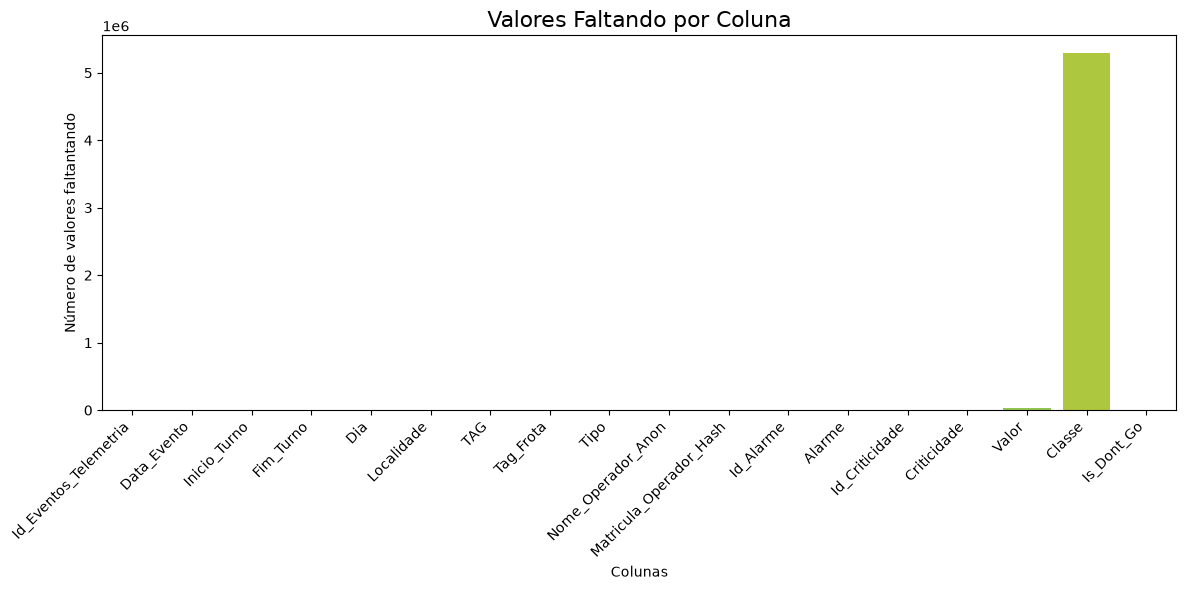

In [5]:


def show_missig_values(dataset):
    rows = dataset.shape[0]
    missing_counts = dataset.isnull().sum().reset_index()
    missing_counts.columns = ["coluna", "valores_faltantes"]
    
    print("Número de valores faltando.")
    for col, val in dataset.isnull().sum().items():
        print(f"{col}: {val} -> {val/rows*100:.2f}%")
    
    plt.figure(figsize=(12,6))
    sns.barplot(data=missing_counts, 
                x="coluna", 
                y="valores_faltantes",
                hue="coluna",
                palette="viridis",
                legend=False,
                dodge=False)
    
    plt.xticks(rotation=45, ha='right')
    plt.title("Valores Faltando por Coluna", fontsize=16)
    plt.xlabel("Colunas")
    plt.ylabel("Número de valores faltantando")
    plt.tight_layout()
    plt.show()
#for i in months:
#    show_missig_values(i)
show_missig_values(jan)

## 🔍 6. Higienização Inicial e Descarte de Atributos

Com o diagnóstico de nulos em mãos, começamos a **limpeza (Data Cleansing)**. Colunas que não possuem informação suficiente para agregar valor preditivo (ex: a variável `Classe`, que tem 97% dos dados faltantes) são descartadas para evitar ruído e processamento desnecessário.

In [6]:
jan = jan.drop(columns="Classe")
print(jan.shape)

(5400002, 17)


## 🔍 7. Análise de Distribuição e Variância de Atributos

Queremos entender a frequência e o comportamento das variáveis restantes. Para isso, criamos funções que geram gráficos automaticamente: histogramas para valores numéricos e gráficos de barra para categóricos.

> 💡 **Dica de Engenharia:** Filtramos automaticamente colunas de variância nula (valores que nunca mudam) ou de altíssima cardinalidade (ex: IDs), já que elas não costumam ser úteis para a divisão do espaço preditivo num modelo tradicional.

In [7]:
def show_distribution(dataset, cut_columns=[], max_categories=50000):
    """
    Exibe a distribuição de colunas relevantes, filtrando IDs, 
    colunas constantes e alta cardinalidade.
    """
    for col in dataset.columns:
        # 1. Filtro de colunas ignoradas manualmente
        if col in cut_columns:
            continue
            
        # 2. Filtro de Variância: Ignora se a coluna tiver apenas 1 valor único (ex: Localidade "Itabira" em tudo)
        unique_count = dataset[col].nunique()
        if unique_count <= 1:
            continue
            
        # 3. Filtro de IDs/Alta Cardinalidade: Se for ID ou Hash (muitos valores únicos em relação ao total)
        # Se mais de 90% dos dados forem únicos, provavelmente é um ID/Chave Primária
        if unique_count > len(dataset) * 0.9:
            continue

        plt.figure(figsize=(10, 5))
        
        # Lógica para colunas NUMÉRICAS
        if pd.api.types.is_numeric_dtype(dataset[col]):
            plt.title(f"Distribuição Numérica: '{col}'", fontsize=12)
            sns.histplot(dataset[col], color="skyblue", bins=30, stat="density", kde=True)
            plt.ylabel("Densidade")
            
        # Lógica para colunas CATEGÓRICAS
        else:
            # Se tiver categorias demais (ex: nomes de operadores), pegamos apenas as Top X
            if unique_count > max_categories:
                data_to_plot = dataset[col].value_counts().head(max_categories)
                plt.title(f"Top {max_categories} Categorias: '{col}'", fontsize=12)
            else:
                data_to_plot = dataset[col].value_counts()
                plt.title(f"Distribuição Categórica: '{col}'", fontsize=12)

            sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette="viridis", hue=data_to_plot.index, legend=False)
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("Frequência")

        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [8]:
def particoes(month: pd.Series, n_chunks: int) -> list:
    chunk_size = len(month) // n_chunks
    
    
    return [month.iloc[i * chunk_size : (i + 1) * chunk_size] for i in range(n_chunks)]
    



In [9]:
partes = particoes(jan, 180)

print(partes[0])


       Id_Eventos_Telemetria                 Data_Evento  \
0                    9372078  2025-01-01 00:00:14.553000   
1                    9372079  2025-01-01 00:00:14.553000   
2                    9372097  2025-01-01 00:02:20.280000   
3                    9372111  2025-01-01 00:02:59.077000   
4                    9372120  2025-01-01 00:03:37.963000   
...                      ...                         ...   
29995               22923577  2025-01-31 00:13:53.397000   
29996               22923580  2025-01-31 00:14:03.000000   
29997               22923584  2025-01-31 00:14:04.550000   
29998               22923587  2025-01-31 00:14:09.477000   
29999               22923588  2025-01-31 00:14:11.217000   

                  Inicio_Turno                Fim_Turno  Dia Localidade  \
0      2024-12-31 18:00:00.000  2025-01-01 06:00:00.000    1    Itabira   
1      2024-12-31 18:00:00.000  2025-01-01 06:00:00.000    1    Itabira   
2      2024-12-31 18:00:00.000  2025-01-01 06:00:00.00

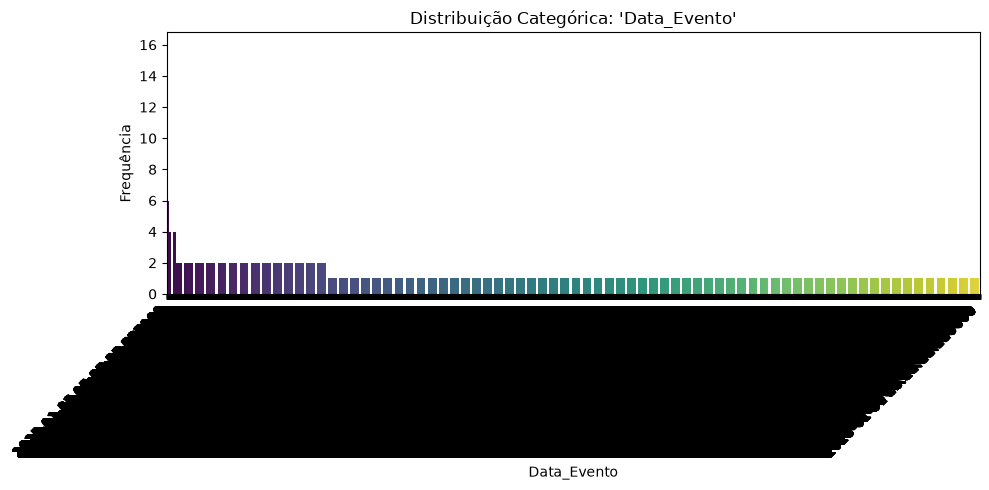

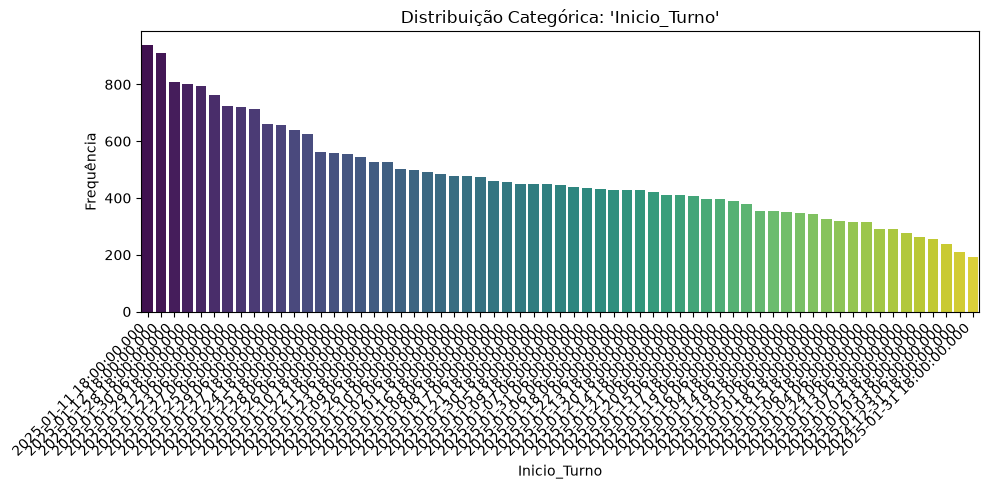

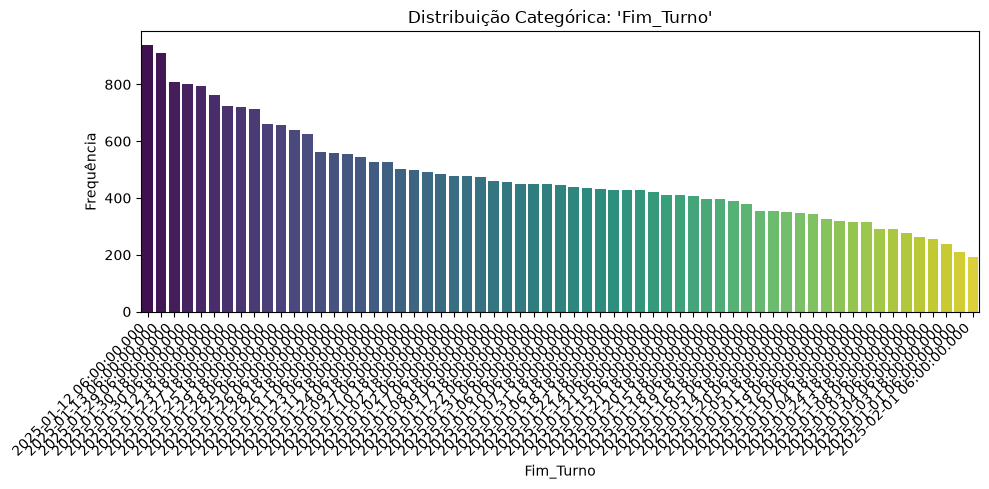

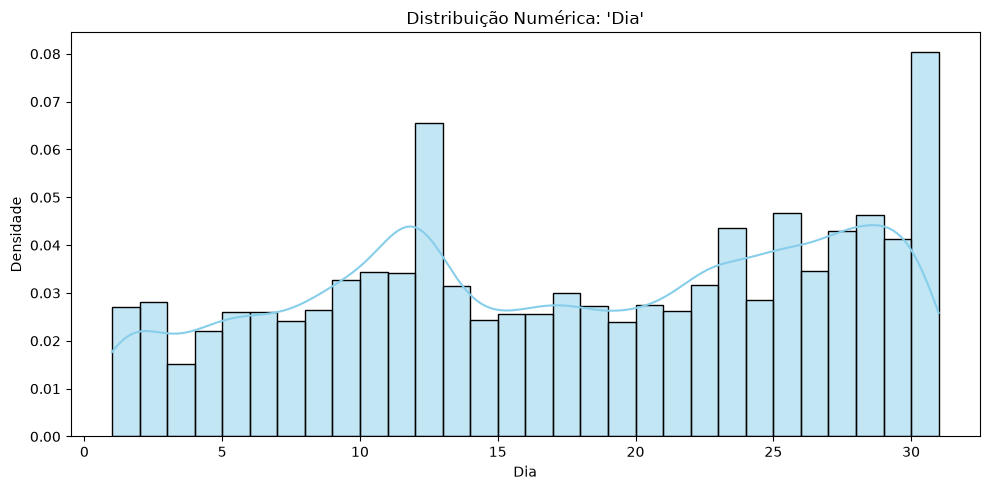

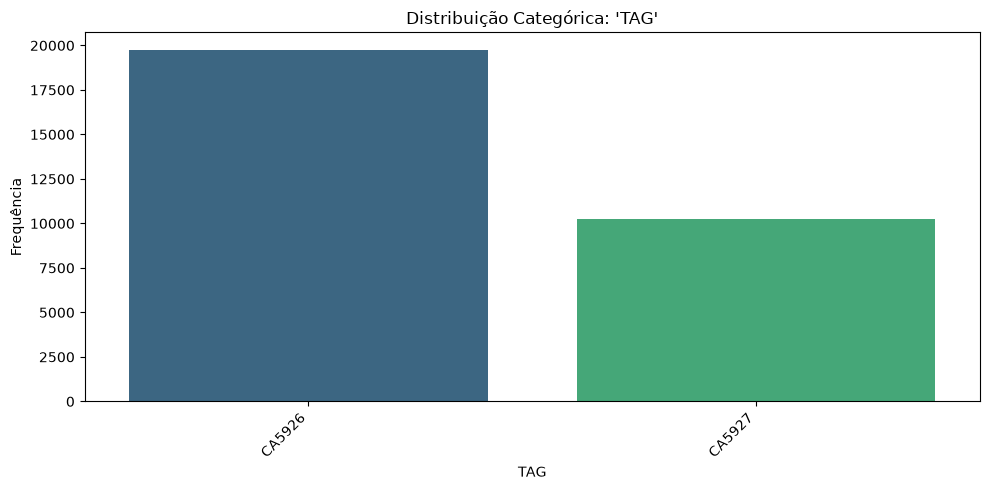

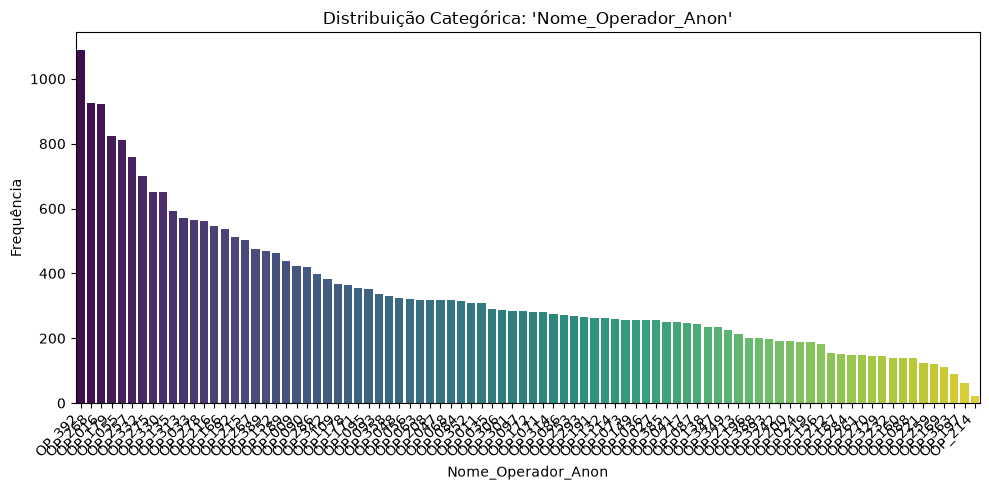

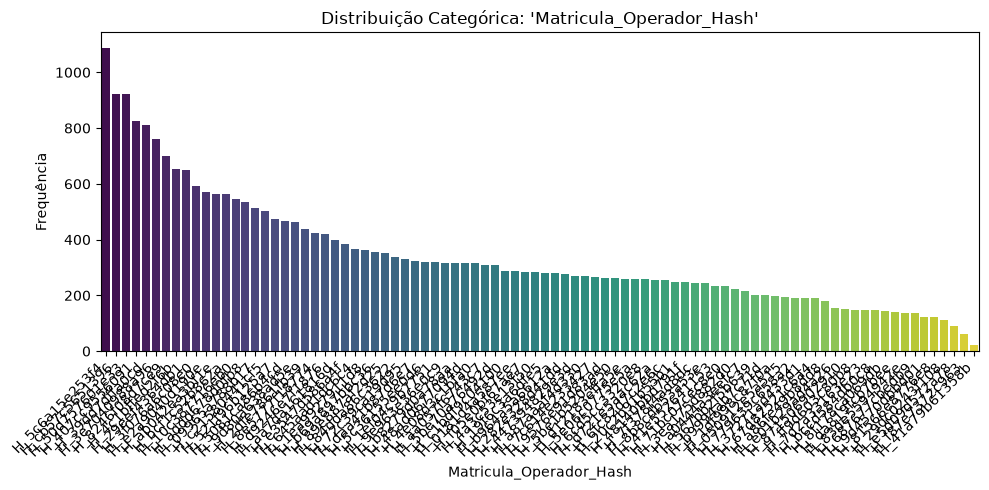

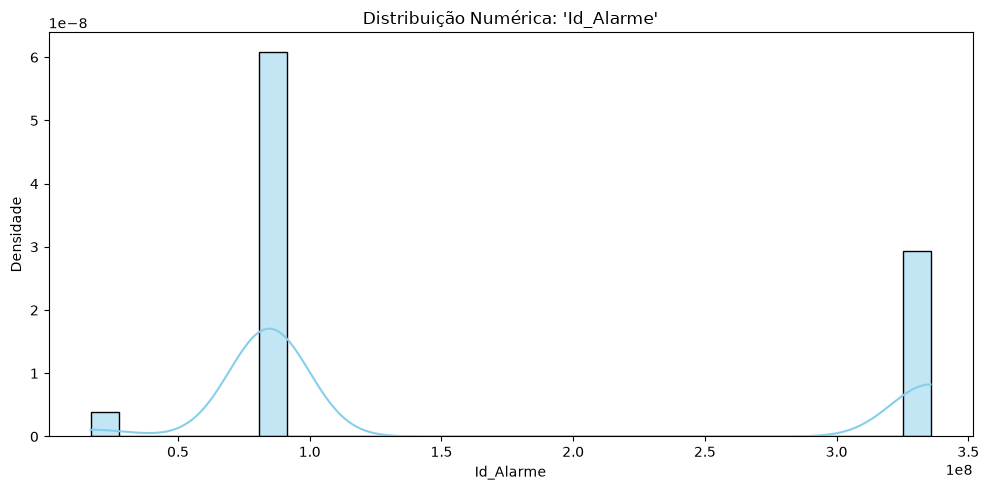

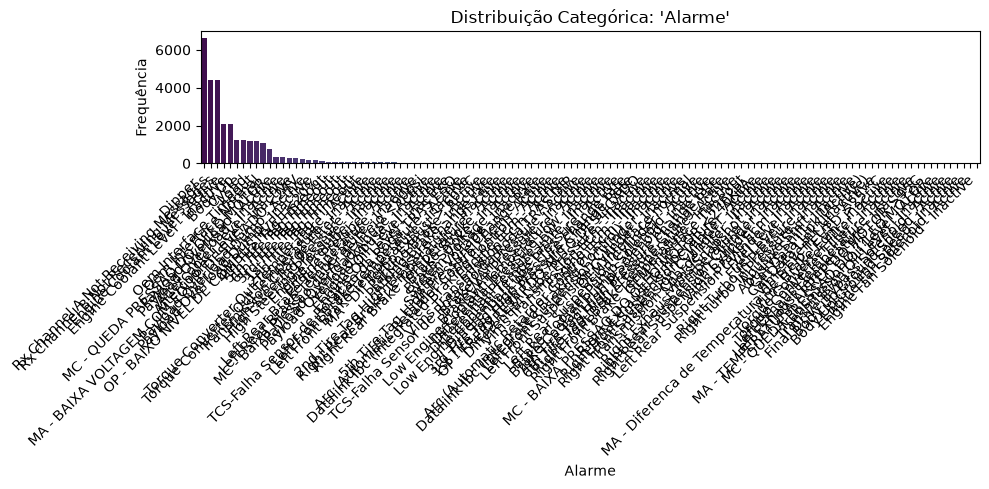

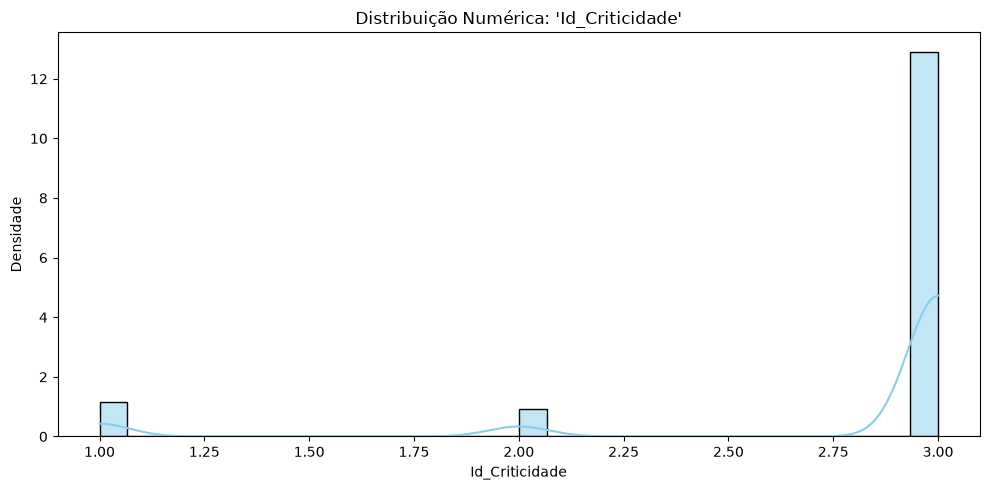

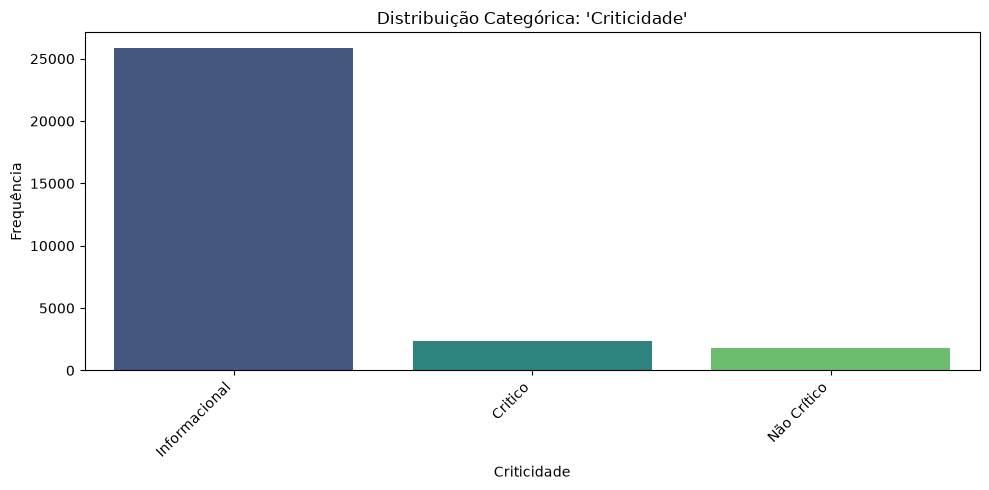

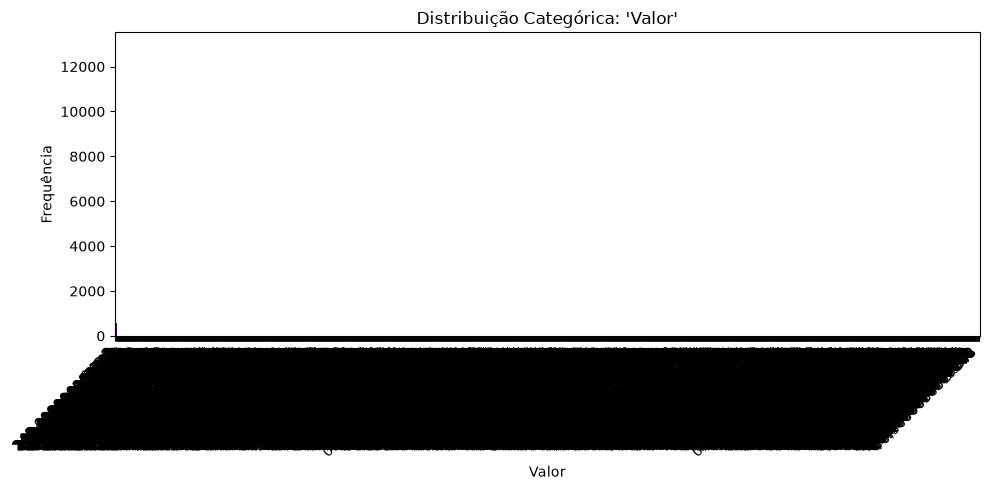

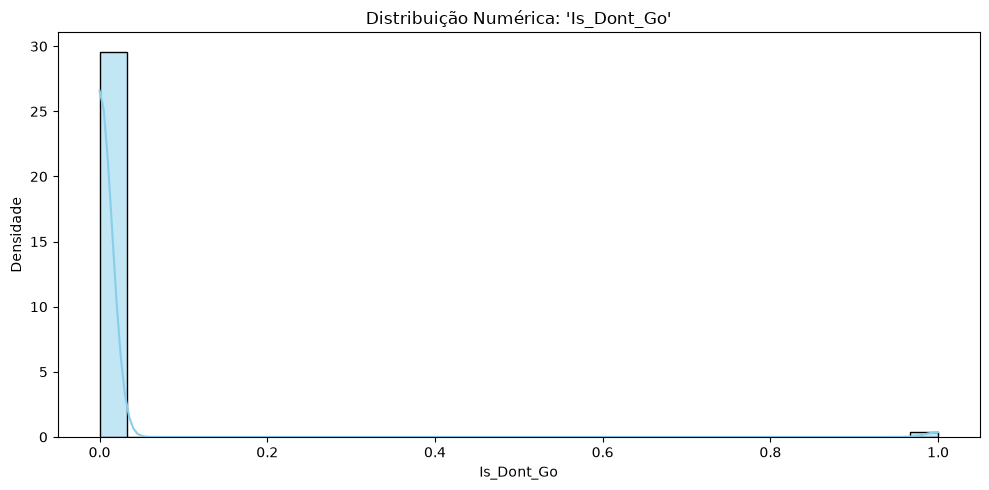

In [10]:
show_distribution(partes[0])

## 🔍 8. Questões de Negócio e Direcionamento Analítico

Os dados por si só não têm valor sem contexto de negócio. A partir da exploração, listamos dúvidas estratégicas a serem validadas com especialistas de domínio para orientar a modelagem.

### 🛠️ 8.1 Perguntas Levantadas para a Área de Negócios

- **Valores Ausentes:** Existem alarmes sem um valor correspondente? Se sim, é seguro descartá-los ou a ausência carrega algum significado (ex: sensor desconectado)?
- **Sazonalidade:** Horários de turno podem ser transformados em blocos lógicos como 'Manhã 1' ou 'Tarde 2' para capturar variação de desgaste ao longo do dia?
- **Feature 'Classe':** Com 97% de dados nulos, vamos apenas descartá-la mesmo?
- **IDs:** Identificadores devem ser puramente categóricos ou há sequências de ID que indicam lotes ou tempo?
- **Muitos Alarmes (Alta Dimensionalidade):** Temos muitas *flags* de alarmes. Como condensá-las de modo prático para o modelo não ficar sobrecarregado (Overfitting)?
- **Agrupamento Semântico:** 'Freios', por exemplo, têm alarmes de pressão, temperatura e falhas auxiliares. Podemos juntá-los num grande grupo 'Alarme_Freio' baseado na criticidade?

## 🔍 9. Exploração de Redundâncias e Agrupamento Semântico

Nesta fase, verificamos a correlação inicial (se existe alguma) entre criticidade e o evento alvo `Is_Dont_Go`. Retiramos identificadores únicos (`Id_Eventos_Telemetria`), características óbvias (`Dia`, `Localidade`) e agrupamos textos de alarmes similares utilizando abordagens de similaridade semântica para diminuir a complexidade do modelo.

In [11]:
a = jan["Alarme"].unique()
b = jan["Criticidade"].unique()
a2 = jan["Alarme"]
b2 = jan["Criticidade"]
c = jan["Is_Dont_Go"]
d = jan["Tipo"].unique()
a, b, a2, b2, c, d

(<StringArray>
 [                      'Rx Channel A Not Receiving Messages',
                        'Rx Channel B Not Receiving Messages',
                                                    'Dipper ',
                                                       'Load',
                           'MC - QUEDA PRESSÃO DO ÓLEO MOTOR',
                                                    'Body Up',
                                                      'Cycle',
                                      'Oem Interface Timeout',
                                       'Oem Interface Normal',
                                  'Payload Overload - Active',
  ...
     'Front Service Brakes Pressure Sensor Or Cable Fail Low',
             'Steer Pump A Pressure Sensor Or Cable Fail Low',
                        'Fuel Level Sensor Or Cable Fail Low',
  'Hydraulic Reservoir Air Pressure Sensor Or Cable Fail Low',
                       'Hydraulic Reservoir Air Pressure Low',
                          'Hydraul

In [12]:
total = 0
casos = 0
for i in zip(b2, c):
    if i[0] == "Critico":
        total = total + 1
    if i[0] == "Critico" and i[1] == 1:
        casos = casos + 1
print(f"A porcentagem é {(casos/total)*100}%")

vai=0
n_vai=0

for target in c:
   if target==0.0:
        vai = vai +1
   else:
        n_vai = n_vai + 1
n_vai, vai, n_vai+vai

A porcentagem é 7.747398261777762%


(2581, 5397421, 5400002)

> ❓ **Dúvida Operacional:** Os dados indicam que apenas 7.7% dos casos críticos resultam em um evento *Don't Go*. Esta proporção reflete o comportamento real da frota ou há algum viés/erro de interpretação na extração da métrica?

In [13]:
jan= jan.drop(columns=['Id_Eventos_Telemetria'])
jan = jan.drop(columns=['Nome_Operador_Anon'])
jan = jan.drop(columns=['Dia'])


### 🧹 Remoção Estratégica de Redundâncias

Para otimizar o processamento e remover *features* que inserem ruído aleatório ou vazamento de dados (*data leakage*), cortamos:
- **`Id_Eventos_Telemetria`**: Chave primária de banco de dados, sem padrão preditivo.
- **`Nome_Operador_Anon`**: Informação espelhada. A matrícula (hash) já identifica o operador de forma segura e limpa.
- **`Dia`**: Dados redundantes já cobertos perfeitamente pela feature principal `Data_Evento`.

In [14]:
print(jan.shape)
jan.head(5)

(5400002, 14)


,Data_Evento,Inicio_Turno,Fim_Turno,Localidade,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Is_Dont_Go
0,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,0
1,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,0
2,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",0
3,2025-01-01 00:02:59.077000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",0
4,2025-01-01 00:03:37.963000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,Itabira,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",0


In [15]:
contador = 0
for i in jan["Localidade"]:
    if i == "Itabira":
        contador = contador + 1
contador

5400002

> 💡 **Nota de Descarte:** A coluna de `Localidade` indica apenas "Itabira" para todos os registros. Por ter variância nula (constante), ela não possui poder discriminatório e não contribui em nada para a inteligência do modelo. Portanto, foi descartada.

In [16]:
jan = jan.drop(columns=['Localidade'])


In [17]:
tipos = jan["Tipo"].unique()
tipos

<StringArray>
['Caminhao', 'Escavadeira']
Length: 2, dtype: str

> 💡 **Dica Analítica (Tipos de Equipamento):** Identificamos que a base atende apenas "Caminhão" e "Escavadeira". No futuro, se houver certeza de que só esses dois existem, a variável poderá ser otimizada para um formato booleano simples (ex: `is_truck`).

In [18]:
print(jan.shape)

(5400002, 13)


In [19]:
def classificar_alarme_detalhado(nome_alarme):
    alarme = str(nome_alarme).upper()
    
    # ---------------------------------------------------------
    # 1. IDENTIFICAÇÃO DA SEVERIDADE (1 ou 2)
    # ---------------------------------------------------------
    # Palavras que indicam falha crítica, impacto direto ou parada
    criticos = ['MC -', 'MA -', 'ACTIVE', 'QUEDA', 'BAIXA PRESSÃO', 'FALHA', 'LOW PRESSURE', '>']
    
    # Palavras que indicam aviso, timeout, inatividade ou operação
    avisos = ['OP -', 'INACTIVE', 'TIMEOUT', 'NORMAL', 'CHANGE RATE', 'ABUSE', 'DUMP', 'LEVEL']
    
    # Define a severidade inicial
    severidade = "1" # Padrão é 1 (Aviso/Menos grave)
    if any(c in alarme for c in criticos) and not any(a in alarme for a in ['INACTIVE', 'NORMAL']):
        severidade = "2" # Se for crítico e NÃO estiver inativo/normal, vira 2

    # ---------------------------------------------------------
    # 2. IDENTIFICAÇÃO DO SISTEMA
    # ---------------------------------------------------------
    sistema = "Outros" # Categoria padrão se não achar nenhuma
    
    # Dicionário de sistemas e suas palavras-chave
    regras_sistemas = {
        "Motor": ['ENGINE', 'COOLANT', 'OIL', 'AFTERCOOLER', 'TURBO', 'EXHAUST', 'ARREF', 'COMBUSTÍVEL', 'PRELUBE', 'FAN'],
        "Freio": ['BRAKE', 'FREIO', 'IBC', 'ARC', 'RETARDO', 'PARKING'],
        "Transmissao": ['TRANSMISSION', 'TORQUE CONVERTER', 'SHIFT', 'DIFFERENTIAL', 'FINAL DRIVE', 'MARCHA'],
        "Suspensao_Lataria": ['SUSPENSION', 'STEERING', 'DIREÇÃO', 'CHASSIS'],
        "Pneu": ['TIRE', 'PNEU'],
        "Carga": ['PAYLOAD', 'DIPPER', 'LOAD', 'CYCLE', 'BODY UP'],
        "Eletronica": ['ECM', 'DATA LINK', 'VIMS', 'CHANNEL', 'OEM', 'VOLTAGEM', 'VOLTAGE', 'SENSOR']
    }
    
    # Busca qual sistema o alarme pertence
    for chave_sistema, palavras_chave in regras_sistemas.items():
        if any(palavra in alarme for palavra in palavras_chave):
            sistema = chave_sistema
            break # Achou o sistema, para de procurar
            
    # ---------------------------------------------------------
    # 3. RETORNA A COMBINAÇÃO (Ex: Freio2, Motor1, Pneu1)
    # ---------------------------------------------------------
    return f"{sistema}{severidade}"

In [20]:
novo = []
for alarme in partes[0]["Alarme"]:
    novo.append(classificar_alarme_detalhado(alarme))
novo
#classificar_alarme(partes[0]["Alarme"])

['Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Outros2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga1',
 'Carga2',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Freio2',
 'Freio2',
 'Freio1',
 'Freio1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'Eletronica1',
 'Eletronica1',
 'Carga1',
 'Carga1',
 'C

> ❓ **Dúvida de Negócio Pendente:** É viável (operacionalmente falando) agrupar "Avisos Operacionais" e "Não Críticos" em uma categoria única de criticidade? Essa simplificação pode reduzir ruído e ajudar o modelo a ser mais decisivo.

In [21]:
head_jan = jan.head()
head_jan

# Exibe o head com cabeçalho destacado, linhas de grade explícitas e alinhamento centralizado
head_jan.style.set_properties(**{
    'background-color': 'white',
    'color': 'black',
    'border': '1px solid #D3D3D3',       # Adiciona linhas entre linhas e colunas
    'text-align': 'center',              # Centraliza o texto das células
    'padding': '8px'
}).set_table_styles([
    {
        'selector': 'th', 
        'props': [
            ('background-color', '#1F4E78'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('border', '1px solid #D3D3D3'), # Adiciona as linhas no cabeçalho também
            ('text-align', 'center'),
            ('padding', '10px')
        ]
    }
])

,Data_Evento,Inicio_Turno,Fim_Turno,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Is_Dont_Go
0,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,0
1,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,0
2,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",0
3,2025-01-01 00:02:59.077000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",0
4,2025-01-01 00:03:37.963000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",0


In [22]:
import matplotlib.pyplot as plt

# 1. Configurando a estrutura gráfica da tabela
fig, ax = plt.subplots(figsize=(50, 2.5)) # Ajuste o tamanho baseado na quantidade de colunas
ax.axis('tight')
ax.axis('off')

# 2. Criando a tabela integrada com os dados do dataframe
table = ax.table(
    cellText=head_jan.values,
    colLabels=head_jan.columns,
    cellLoc='center',
    loc='center'
)

# 3. Ajustando proporções de espaçamento e fontes
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.8) # Alarga as linhas verticalmente para um aspecto profissional

# 4. Aplicando a estilização das bordas, cabeçalho e preenchimento
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#B0B0B0')  # Linhas divisórias cinzas explícitas
    cell.set_linewidth(1.2)        # Espessura da linha separadora
    
    if row == 0:
        # Cabeçalho Azul Escuro padrão do projeto
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1F4E78')
    else:
        # Linhas de dados com sutil alternância de fundo para melhor leitura
        if row % 2 == 0:
            cell.set_facecolor('#F9FBFD')
        else:
            cell.set_facecolor('#FFFFFF')

# 5. Salvando nos formatos solicitados com alta resolução
plt.savefig('head_janeiro.png', bbox_inches='tight', dpi=300)
plt.savefig('head_janeiro.svg', bbox_inches='tight')
plt.close()

print("Imagens 'head_janeiro.png' e 'head_janeiro.svg' geradas com sucesso!")

Imagens 'head_janeiro.png' e 'head_janeiro.svg' geradas com sucesso!


In [23]:
# Substitua o 'caminho_e_nome_do_arquivo.csv' pelo local onde deseja salvar
jan.to_csv('jan_limpo.csv', index=False)